
### Preliminaries
A **vector field** 
$v : [0, 1] \times \mathbb{R}^d \rightarrow \mathbb{R}^d $ assigns a time-dependent vector to every point in space. This vector tells a particle how fast and in which direction it should move if placed at that location. The direction of the vector indicates the direction of motion, while its magnitude corresponds to the speed (or velocity) of the particle. Imagine placing a tiny arrow at every point in space, each arrow shows the local direction and strength of movement.


The **flow** of a vector field describes how a point moves through space over time under the influence of that field.  
In other words, it tracks the trajectory of a particle as it follows the directions given by the vector field.

To obtain the flow, we **integrate the vector field** starting from an initial point $x_0$. This yields a curve $\phi_t(x)$ that satisfies the ordinary differential equation:

$$
\frac{d}{dt} \phi_t(x) = v_t(\phi_t(x)), \quad \phi_0(x_0) = x_0
$$

This trajectory $\phi_t(x)$ tells us where the particle will be at any time $t \in [0, 1]$, assuming it moves according to the vector field $v_t$.
The diagram below illustrates the relation between a vector field and its corresponding flow.

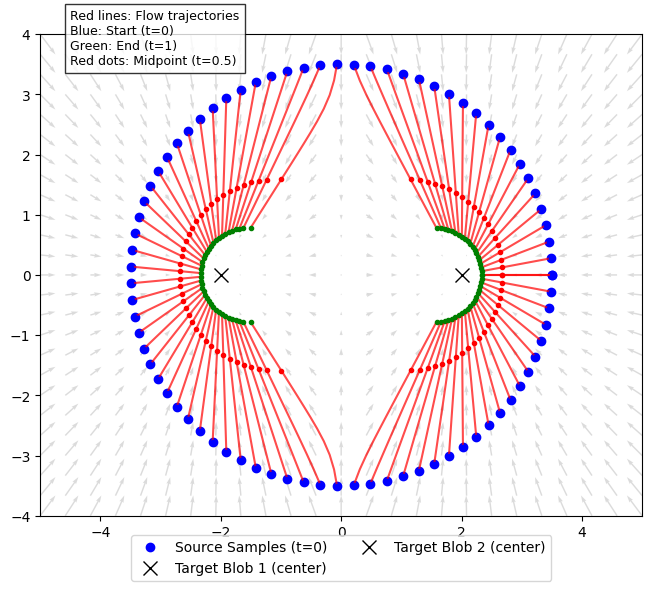

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

def vector_field(t, x):
    mu1 = np.array([-2.0, 0.0])  
    mu2 = np.array([2.0, 0.0])   
    strength = 1.5

    dist1 = np.linalg.norm(x - mu1)
    dist2 = np.linalg.norm(x - mu2)
    w1 = np.exp(-dist1**2)
    w2 = np.exp(-dist2**2)
    w_sum = w1 + w2
    w1 /= w_sum
    w2 /= w_sum

    direction = w1 * (mu1 - x) + w2 * (mu2 - x)
    return strength * direction

x = np.linspace(-5, 5, 25)
y = np.linspace(-4, 4, 25)
X, Y = np.meshgrid(x, y)
U = np.zeros_like(X)
V = np.zeros_like(Y)

for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        vec = vector_field(0, np.array([X[i, j], Y[i, j]]))
        U[i, j] = vec[0]
        V[i, j] = vec[1]

theta = np.linspace(0, 2 * np.pi, 80)
r = 3.5
source_samples = np.stack([r * np.cos(theta), r * np.sin(theta)], axis=1)

trajectories = []
for pt in source_samples:
    sol = solve_ivp(vector_field, t_span=[0, 1], y0=pt, t_eval=np.linspace(0, 1, 20))
    trajectories.append(sol.y.T)

plt.figure(figsize=(8, 6))
plt.quiver(X, Y, U, V, color='lightgray', alpha=0.8)
plt.plot(source_samples[:, 0], source_samples[:, 1], 'bo', label='Source Samples (t=0)')

for traj in trajectories:
    plt.plot(traj[:, 0], traj[:, 1], 'r-', alpha=0.7)
    plt.plot(traj[0, 0], traj[0, 1], 'bo', markersize=3)               
    plt.plot(traj[len(traj)//2, 0], traj[len(traj)//2, 1], 'ro', markersize=3)  
    plt.plot(traj[-1, 0], traj[-1, 1], 'go', markersize=3)          

plt.plot(-2, 0, 'kx', markersize=10, label='Target Blob 1 (center)')
plt.plot(2, 0, 'kx', markersize=10, label='Target Blob 2 (center)')

plt.text(-4.5, 3.5, "Red lines: Flow trajectories\nBlue: Start (t=0)\nGreen: End (t=1)\nRed dots: Midpoint (t=0.5)",
         fontsize=9, bbox=dict(facecolor='white', alpha=0.8))

plt.xlim(-5, 5)
plt.ylim(-4, 4)
plt.gca().set_aspect('equal')
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=2)
plt.tight_layout()
plt.show()


More genebrally, an **ordinary differential equation (ODE)** describes how a system evolves deterministically over time. It takes the form:

$$
\frac{dx}{dt} = f(x, t)
$$

Here, $f(x, t)$ is the vector field that specifies the direction and speed of change at each point $x$ and time $t$. Solving this ODE gives a trajectory $x(t)$, which describes how a point $x_0$ moves through space over time. To compute this flow in practice, we solve the ODE numerically. There are various solvers; one simple example is the **Euler method**, which is available in frameworks like PyTorch and SciPy. Below you can fine a simple example using this method.

ODE equation:
$$
\frac{dx}{dt} = -x, x(0) = 1
$$
Exact solution: 
$$
x(t) = e^{-t}
$$



[notice] A new release of pip is available: 23.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


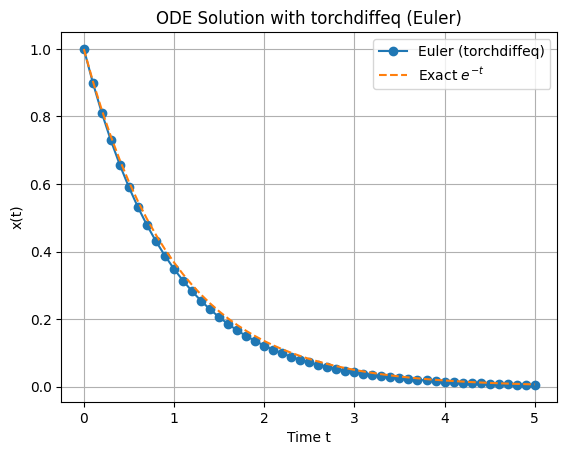

In [ ]:
import torch
import matplotlib.pyplot as plt
! pip install torchdiffeq -q
from torchdiffeq import odeint

class VectorField(torch.nn.Module):
    def forward(self, t, x):
        return -x

x0 = torch.tensor([1.0])
t = torch.linspace(0, 5, 51)  

x_euler = odeint(
    func=VectorField(),
    y0=x0,
    t=t,
    method='euler'
).squeeze()

x_exact = torch.exp(-t)

plt.plot(t, x_euler, label="Euler (torchdiffeq)", marker='o')
plt.plot(t, x_exact, label="Exact $e^{-t}$", linestyle='--')
plt.xlabel("Time t")
plt.ylabel("x(t)")
plt.title("ODE Solution with torchdiffeq (Euler)")
plt.legend()
plt.grid(True)
plt.show()

### Flow-matching for generative modeling

So far, we've seen how a vector field can move individual data samples over time. As the samples move, their distribution changes from an initial distribution $ p_0$ to a new one $p_1$. If we know the vector field (and hence the flow ), we can compute how the data distribution transforms over time. This idea forms the basis of **flow matching** in generative modeling.

There are many approaches in deep generative modeling that aim to transform a simple distribution (like a standard Gaussian) into a complex one (like real-world images). This is essentially what happens in models like VAEs, normalizing flows, and diffusion models. What makes flow matching unique is that it directly learns the vector field that transports the data distribution from $p_0$ to $p_1$. Interestingly, the authors show that this formulation is general enough to encompass diffusion modelsas a special case.

Before diving deeper, consider the following equation, which describes how a distribution $p_0$ transforms under a flow $\phi_t$:

$$
[\phi_t]_∗ p_0(x) = p_0(\phi_t^{-1}(x)) \cdot \left| \det \left( \frac{\partial \phi_t^{-1}(x)}{\partial x} \right) \right|
$$

This equation tells us how to compute the **pushforward** of a density $p_0$ through a flow $\phi_t$. A derivation of this formula in the simple one-dimensional case is provided at the end of this article to help build intuition.

The core idea in the **Flow Matching** paper is to learn a vector field $v_t(x)$ such that its induced flow $\phi_t$ pushes the distribution $p_0$ toward $p_1$. To do this, we could directly regress the vector field:

$$
\mathcal{L}_{\text{FM}}(\theta) = \mathbb{E}_{t, p_t(x)} \left\| v_\theta(x, t) - u_t(x) \right\|^2
$$

Here:
- $u_t(x)$ is the ground-truth velocity of a stochastic process (e.g., Brownian bridge),
- $v_\theta(x, t)$ is the neural network we train to match it,
- $p_t(x)$ is the marginal distribution of the process at time $t$.


But, this formulation requires computing expectations over all possible noise paths (we don’t have access to the exact form of $p_t(x)$) which makes it intractable.

To resolve this, the authors propose **Conditional Flow Matching (CFM)**, a variant of the loss where we condition on sample pairs $(x_0, x_1) \sim p_0 \times p_1$ and define a known interpolation (e.g., Brownian bridge, straight line with noise):

$$
\mathcal{L}_{\text{CFM}}(\theta) = \mathbb{E}_{x_0, x_1, t} \left\| v_\theta(x_t, t) - u_t(x_t, x_0, x_1) \right\|^2
$$

This version is tractable and can be implemented as a simple regression over samples drawn from the training dataset.

As such, in this setup, instead of learning to reverse a diffusion process (as in score-based models), we directly learn a deterministic vector field that pushes points from $p_0$ to $p_1$, with the help of well-defined interpolation paths.This makes training simple, stable, and compatible with standard supervised regression.


Now that we’ve trained our vector field $v_\theta(x, t)$ using CFM objective, we can generate new samples by integrating over the learned vector field forward in time starting from a base distribution $p_0$. This hopefully gives us a point in the target (data) distribution $p_1$.

An interesting aspect of flow matching is that we are free to define different interpolation paths, the trajectories that connect points from $p_0$ to $p_1$. These paths determine the target velocity field $u_t(x)$ used for training.

For example, we can choose:
- A straight-line interpolation between samples $x_0$ and $x_1$ (referred to as optimal transport path in the paper)
- A noisy interpolation like a *Brownian bridge* which results in the diffusion denoising path

The authors show that by defining the interpolation appropriately, we can recover and generalize many generative models. Check out this [implementation from Georges Le Bellier](https://github.com/lebellig/flow-matching/tree/main) to better understand the details.

### Stable diffusion 3.5

Stable Diffusion 3 (SD3) differs from its predecessors in architecture and training objective.
From an architectural perspective, it adopts the DiT-style transformer backbone proposed in *Diffusion Transformers (DiT)*, replacing the U-Net used in earlier diffusion models.

From a training standpoint, SD3 switches to a flow matching objective, different from previous score-based diffusion models. More specifically, the model is trained to regress the vector field as elaborated in the follwing.

In the SD3 paper, the flow from the source distribution to the target distribution is defined using an affine transformation. At each time step $t$, the flow moves a sample $x_0$ according to:

$$
\psi_t(\cdot \mid \epsilon) : x_0 \mapsto a_t x_0 + b_t \epsilon
$$

Here:
- $x_0$ is the original data sample,
- $\epsilon \sim \mathcal{N}(0, I)$ is a standard Gaussian noise vector,
- $a_t$, $b_t$ are time-dependent scalar coefficients that control how data and noise are mixed as time progresses.

This defines a forward trajectory that transforms clean data into noise, similar to the forward process in diffusion models.  

Accordingly, the vector field is defined as the time derivative of the flow:

$$
u_t(z \mid \epsilon) := \psi_t'\left(\psi_t^{-1}(z \mid \epsilon) \mid \epsilon\right)
$$

This means the vector field $u_t$ gives the instantaneous velocity of a point $z$ at time $t$, conditioned on the noise $\epsilon$.  
To compute it, we first apply the inverse transformation $\psi_t^{-1}(z \mid \epsilon)$ to recover the original (denoised) point $x_0$, and then evaluate the time derivative of the flow at that location. Note that the trajectory $z_t$ is defined as a function of $x_0$ and $\epsilon$, the only way to compute its time derivative (i.e. velocity) is by differentiating the path with respect to time starting at $x_0$.

The conditional vector field $u_t(z \mid \epsilon)$ plays a central role in training.
In particular, SD3 uses it in the Conditional Flow Matching (CFM) objective.  
The model is trained to regress the ground-truth velocity of a sample $z$ at time $t$, conditioned on noise $\epsilon$:

$$
\mathcal{L}_{\text{CFM}} = \mathbb{E}_{t, p_t(z \mid \epsilon), p(\epsilon)} \left\| v_\theta(z, t) - u_t(z \mid \epsilon) \right\|_2^2
$$

Here:
- $v_\theta(z, t)$ is the model's predicted velocity at time $t$,
- The expectation is over time $t$, conditional samples $z$, and noise $\epsilon$.

This loss is just a supervised regression objective training a neural network to match a known velocity field.
Based on the definition of the flow $\psi_t(x_0 \mid \epsilon)$, the authors further simplify the loss term.Let’s walk through it step by step.


The flow is defined as:

$$
\psi_t(x_0 \mid \epsilon) = a_t x_0 + b_t \epsilon
$$

The time derivative of the flow is:

$$
\psi_t'(x_0 \mid \epsilon) = a_t' x_0 + b_t' \epsilon
$$

To evaluate the derivative at a given noisy latent $z$, we need to recover $x_0$ by inverting the flow:

$$
\psi_t^{-1}(z \mid \epsilon) = \frac{z - b_t \epsilon}{a_t}
$$

Plugging this into the derivative gives the explicit velocity field:

$$
u_t(z \mid \epsilon) = \psi_t'\left(\psi_t^{-1}(z \mid \epsilon) \mid \epsilon\right) = \frac{a_t'}{a_t} z - \epsilon \cdot b_t \left( \frac{a_t'}{a_t} - \frac{b_t'}{b_t} \right)
$$

The authors then define the signal to noise ratio and it's derivative based on the following:
$$
\lambda_t := \log \frac{a_t^2}{b_t^2}
,
\lambda_t' = 2\left( \frac{a_t'}{a_t} - \frac{b_t'}{b_t} \right)
$$
Replacing this notion results in:
$$
u_t(z \mid \epsilon) = \frac{a_t'}{a_t} z - \frac{b_t}{2} \lambda_t' \epsilon
\tag{10}
$$


Next, we plug this term into the Conditional Flow Matching loss:

$$
\mathcal{L}_{\text{CFM}} = \mathbb{E}_{t, p_t(z \mid \epsilon), p(\epsilon)} \left\| v_\theta(z, t) - \frac{a_t'}{a_t} z + \frac{b_t}{2} \lambda_t' \epsilon \right\|_2^2
\tag{11}
$$

Now this is interesting! Define the predicted noise $\epsilon_\theta(z, t)$ as:

$$
\epsilon_\theta(z, t) := \frac{-2}{\lambda_t' b_t} \left( v_\theta(z, t) - \frac{a_t'}{a_t} z \right)
$$

Then the loss becomes very similar to the noise prediction objective in diffusion setting:

$$
\mathcal{L}_{\text{CFM}} = \mathbb{E}_{t, p_t(z \mid \epsilon), p(\epsilon)} \left( \frac{b_t}{2} \lambda_t' \right)^2 \left\| \epsilon_\theta(z, t) - \epsilon \right\|_2^2
\tag{12}
$$

To recap:

- The model predicts noise $\epsilon$, similar to score-based diffusion models.
- But it still operates within the flow matching framework, which is deterministic and ODE-based.
- The final loss looks just like the standard noise prediction loss, but weighted by a time-dependent scalar.

For details about the implementation and the sampling method used in inference check out [HuggingFace](https://huggingface.co/docs/diffusers/main/en/api/pipelines/stable_diffusion/stable_diffusion_3).

### References
The content of this blog is based on checking many resources online including:

- [Scaling Rectified Flow Transformers for High-Resolution Image Synthesis](https://arxiv.org/abs/2403.03206)
- [Flow Matching for Generative Modeling](https://arxiv.org/abs/2210.02747)
- [Flow Matching for Generative Modeling (Paper Explained)](https://www.youtube.com/watch?v=7NNxK3CqaDk)  
- [TUM AI Lecture Series](https://www.youtube.com/watch?v=nrKKLJXBSw0)  
- [The flow of a vector field](https://www.youtube.com/watch?v=q013xEHvMac&t=220s)
- [FlowMatchEulerDiscreteScheduler](https://huggingface.co/docs/diffusers/en/api/schedulers/flow_match_euler_discrete)
